In [2]:
import os
import numpy as np
import time
import pandas as pd
from scipy import interpolate
import pickle
import sys
from astropy.io import ascii
from astropy.table import Table
from astropy import units as u
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap

In [3]:
def Enquiry(HashTable, InfoDict, Band1, Band2, dT1, dT2, dMag=None, Color=None):
    if abs(dT1) > abs(dT1-dT2):
        dT1, dT2 = dT1-dT2, -dT2    
    Ind1 = InfoDict['BandPairs'].index(Band1+Band2)
    #index for where 1st filter is, 2nd index for 2nd filter
    dT1grid = InfoDict['dT1s'][ abs( dT1 - InfoDict['dT1s'] ).argmin() ]
    dT2grid = InfoDict['dT2s'][ abs( dT2 - InfoDict['dT2s'] ).argmin() ]
    
    TimePairGrid = np.array([ InfoDict['dT1s'][ abs( dT1 - InfoDict['dT1s'] ).argmin() ], InfoDict['dT2s'][ abs( dT2 - InfoDict['dT2s'] ).argmin() ] ])
    # above will need some difference to set limit on difference in times
    Ind2 = np.where( (np.array(InfoDict['TimePairs']) == TimePairGrid ).all(axis=1) )[0][0]
    Results = HashTable[Ind1, Ind2]

    if dMag == None:
        pass        
    elif dMag<InfoDict['BinMag'][0] or dMag>=InfoDict['BinMag'][-1]:
        raise ValueError('The value of dMag is out of boundary, the available interval is [{:.2f}, {:.2f}).'.format(InfoDict['BinMag'][0], InfoDict['BinMag'][-1]))        
    else:
        Results = Results[np.where( dMag >= InfoDict['BinMag'] )[0][-1]]       

    if Color == None:
        pass        
    elif Color<InfoDict['BinColor'][0] or Color>=InfoDict['BinColor'][-1]:
        raise ValueError('The value of Color is out of boundary, the available interval is [{:.2f}, {:.2f}).'.format(InfoDict['BinColor'][0], InfoDict['BinColor'][-1]))
        
    else:
        Results = Results[..., np.where( Color >= InfoDict['BinColor'] )[0][-1] ]

    return Results

In [4]:
def loadCubeFile(FilePath):
    
    FileTime = FilePath[FilePath.find('Cube_')+4: FilePath.rfind('__')]
    
    with open(FilePath, 'rb') as f:
        InfoDict = pickle.load(f)
        print(InfoDict)
        HashTable = pickle.load(f)
    
    dT1Range = [InfoDict['dT1s'][0], InfoDict['dT1s'][-1]]
    dT2Range = [InfoDict['dT2s'][0], InfoDict['dT2s'][-1]]    
    dT1step = ( InfoDict['dT1s'][1:] - InfoDict['dT1s'][:-1] ).min()
    dT2step = ( InfoDict['dT2s'][1:] - InfoDict['dT2s'][:-1] ).min()
        
    StartObjNo = 'n/a'
    
    if 'StartObjNo' in InfoDict:
        StartObjNo = InfoDict['StartObjNo']
        
   # print('{:<35}ObjectNo: {:>5}, start at {:>3}. dT1 range = {}, step = {:>3}. dT2 range = {}, step = {:>3}. BandpairNo: {}.'.format(
   #     InfoDict['EventNames']+FileTime, InfoDict['ObjectNo'], StartObjNo, dT1Range, dT1step, dT2Range, dT2step, len(InfoDict['BandPairs'])))

    # InfoDict['OutliersRatio'] = InfoDict['Outliers'] / HashTable.sum()

    if 'Outliers' in InfoDict:
        print('\t{} outliers found, the ratio to the max value is {:.12f}.'.format(InfoDict['Outliers'], InfoDict['OutliersRatio']) )
        print('\tdMag range is {}, \n\tColor range is {}.'.format( InfoDict['dMagRange'], InfoDict['ColorRange'] ) )

    if 'Overflow' in InfoDict:
        print('\tData in the HashTable overflowed, the minimun value is {}.'.format(InfoDict['Overflow']))
        
    return InfoDict, HashTable;

In [5]:
def PlotSlice(HashTable1, InfoDict1, Band1, Band2, dT1, dT2, ax = None):
    # cut_gist_heat = ListedColormap(plt.colormaps["gist_heat"](np.linspace(0, 0.9, 256)))
    
    if ax == None: 
        fig, ax = plt.subplots(1,1)

    

    Map1 = Enquiry(HashTable1, InfoDict1, Band1, Band2, dT1, dT2) * 10000000

    ax.pcolor(InfoDict['BinMag'], InfoDict['BinColor'], np.transpose(Map1)+1,
                        norm=LogNorm(1, vmax=Map1.max()+1), cmap="gist_grey")

        # ax.scatter(Data[0], Data[1], c='mediumpurple', s=1, alpha=0.1, )


    ax.set_xlim([-1.5, 2])
    ax.set_ylim([-5, 8]) 


In [6]:
def PlotSliceWithTwoHists(HashTable1, InfoDict1, HashTable2, InfoDict2, Band1, Band2, dT1, dT2, ax = None):
    cut_gist_heat = ListedColormap(plt.colormaps["gist_heat"](np.linspace(0, 0.9, 256)))
    
    if ax == None: 
        fig, ax = plt.subplots(1,1)
    Map1 = Enquiry(HashTable1, InfoDict1, Band1, Band2, dT1, dT2) * 10000000
    Map2 = Enquiry(HashTable2, InfoDict2, Band1, Band2, dT1, dT2) * 10000000
    
    ax.pcolor(InfoDict['BinMag'], InfoDict['BinColor'], np.transpose(Map1)+1,
                       norm=LogNorm(1, vmax=Map1.max()+1), cmap='gist_gray')
    ax.pcolor(InfoDict2['BinMag'], InfoDict2['BinColor'], np.transpose(Map2),
                       norm=LogNorm(1, vmax=Map2.max()-1), cmap=cut_gist_heat)
            
    ax.set_xlim([-1.5, 2])
    ax.set_ylim([-5, 8]) 

In [7]:
EventNames = ['AGN', 'CART', 'EB', 'ILOT', 'KN_B19', 'KN_K17', 'MIRA', 'Mdwarf',
              'PISN', 'RRL', 'SLSN-I', 'SNII-NMF', 
              'SNII-Templates', 
              'SNIIn',
              'SNIa-91bg', 'SNIa-SALT2', 'SNIax', 'SNIbc-MOSFIT',
              'SNIbc-Templates', 
              'TDE', 'V19_CC+HostXT', 'uLens-Binary',
              'uLens-Single-GenLens', 
              'uLens-Single_PyLIMA',
             ]

In [8]:
PathCubeFolder = '/lustre/lrspec/users/4300/cube/Data/Datacube/All_Events'
CubeFileNames = os.listdir(PathCubeFolder)
CubeFileNames = [ ii for ii in CubeFileNames if '.pkl' in ii and "211_223" in ii]

In [9]:
# RateDict = {key:1 for key in EventNames}
# RateDict['KN_B19'] = 0
# RateDict['KN_K17'] = 0

# #Calculate the total cube

# CubeFileName = CubeFileNames[0]
# EventName = CubeFileName[ CubeFileName.rfind('__')+2 : CubeFileName.rfind('.') ]
# CubeFilePath = os.path.join(PathCubeFolder, CubeFileName)

# with open(CubeFilePath, 'rb') as f:
#     InfoDict = pickle.load(f)
#     Cube = pickle.load(f)

# TotalCube = Cube * ( RateDict[EventName] / InfoDict.pop('ObjectNo') )

# del InfoDict['EventName']
# del InfoDict['PointsPerDay']
# del InfoDict['dMagRange']
# del InfoDict['ColorRange']
# InfoDict.pop('Outliers', None)
# InfoDict.pop('OutliersRatio', None)
# InfoDict.pop('Overflow', None)

# for CubeFileName in CubeFileNames[1:]:
    
#     print('|', end='')

#     EventName = CubeFileName[ CubeFileName.rfind('__')+2 : CubeFileName.rfind('.') ]
#     CubeFilePath = os.path.join(PathCubeFolder, CubeFileName)

#     with open(CubeFilePath, 'rb') as f:
#         infoDict = pickle.load(f)
#         Cube = pickle.load(f)

#     TotalCube = TotalCube + Cube * ( RateDict[EventName] / infoDict.pop('ObjectNo') )

# if TotalCube.min() < 0:
#     print('Data overflow, please check!')

In [18]:
# TotalCubeNorm = TotalCube / TotalCube.max(-1, keepdims=True).max(-2, keepdims=True)
# np.nan_to_num(TotalCubeNorm, copy=False);

In [21]:
# with open('/lustre/lrspec/users/4300/cube/Data/Datacube/211_223_TotalCubeNorm.pkl', 'wb') as f:
#     pickle.dump(InfoDict, f)
#     pickle.dump(TotalCubeNorm, f ) 

(-6.0, 6.0)

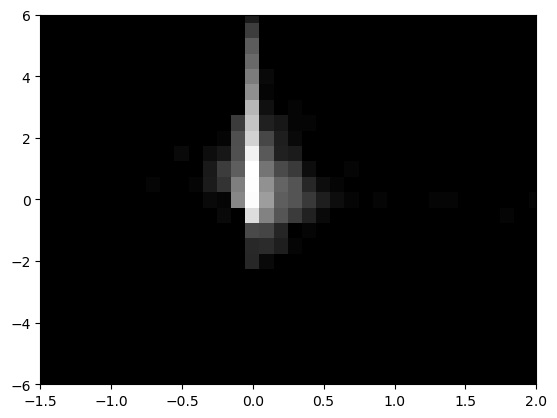

In [10]:
TotalCubePath = "/lustre/lrspec/users/4300/cube/Data/Datacube/211_223_TotalCubeNorm.pkl"
with open(TotalCubePath, 'rb') as f:
    InfoDict = pickle.load(f)
    Cube = pickle.load(f)
        
# CubeNorm = Cube / Cube2.max(-1, keepdims=True).max(-2, keepdims=True)
# np.nan_to_num(CubeNorm2, copy=False);


bandpairs = ["ir","gr"]
timepairs = [(-12,-223),(33,-189)]

q=1

Map1 = Enquiry(Cube, InfoDict, bandpairs[q][0], bandpairs[q][1], timepairs[q][0], timepairs[q][1])    

Map1 = Map1*100000

plt.pcolor(InfoDict['BinMag'], InfoDict['BinColor'], np.transpose(Map1)+1,
           norm=LogNorm(1, vmax=Map1.max()-1), cmap='gist_gray')
plt.xlim([-1.5, 2])
plt.ylim([-6, 6])


In [14]:
dp2 = ascii.read("/lustre/lrspec/users/4300/cube/Data/Phot/DP2query3.ecsv")
dp2 = dp2[dp2["psfFlux"]>0]
sel_objs = np.unique(dp2["diaObjectId"])[0:100]
dp2_sel = dp2[np.isin(dp2["diaObjectId"],sel_objs)]

In [15]:
# pref_dT1s = np.arange(-480, 481, 15)
# pref_dT2s = np.hstack(( np.arange(-1920, -1439, 30), np.arange(-480, 481, 30), np.arange(1440, 1921, 30) )) 
pref_dT1s = np.arange(-480, 481, 1)
pref_dT2s = np.hstack((np.arange(-480, 481, 1))) 
thrs = {'u': 23.9, 'g': 25.0, 'r': 24.7, 'i': 24.0, 'z': 23.3, 'y': 22.1}

In [16]:
obj_dfs = []

for n, obj in enumerate(np.unique(dp2_sel["diaObjectId"])):
    timepairs = []
    bandpairs = []
    dMags = []
    colors = []
    name = []
    dp2_obj = dp2_sel[dp2_sel["diaObjectId"] == obj]
    
    for i,mjd1 in enumerate(dp2_obj["expMidptMJD"]):
        dT1s2 = []
        dT2s2 = []
        dMs = []
        bps = []
        cs = []
        for j, mjd2 in enumerate(dp2_obj["expMidptMJD"]):
            if dp2_obj["band"][i] != dp2_obj["band"][j]:
                dT1 = -(mjd1-mjd2)*u.day
                dT1 = int((dT1.to(u.min)/u.min))

                
                if dT1 in pref_dT1s:
                    M1 = -2.5*np.log10(dp2_obj["psfFlux"][i])+31.4
                    M2 = -2.5*np.log10(dp2_obj["psfFlux"][j])+31.4
                    color = M1-M2
                    #= dp1_obj["psfFlux"][i] / dp1_obj["psfFlux"][j]
                    BandPair = dp2_obj["band"][i]+dp2_obj["band"][j]
                        
                    
                    dT1s2.append(dT1)
                    cs.append(color)
                    bps.append(BandPair)
            
            else:
                dT2 = -(mjd1-mjd2)*u.day
                dT2 = int((dT2.to(u.min)/u.min))

                
                if dT2 in pref_dT2s and dT2 != 0:
                    M1 = -2.5*np.log10(dp2_obj["psfFlux"][i])+31.4
                    M2 = -2.5*np.log10(dp2_obj["psfFlux"][j])+31.4
                    
                    # dflux = (dp1_obj["psfFlux"][i] / dp1_obj["psfFlux"][j])
    
                    dT2s2.append(dT2)
                    #dMs.append((-2.5*np.log10(dflux))*np.sign(dT2))
                    dMs.append((M1-M2)*np.sign(dT2))
            
        for k, dT1 in enumerate(dT1s2):
            for h, dT2 in enumerate(dT2s2):
                timepairs.append((dT1,dT2))

                bandpairs.append(bps[k])
                colors.append(cs[k])
                
                dMags.append(dMs[h])

                name.append(obj)
                    

    obj_pts = pd.DataFrame()
    obj_pts["Timepairs"] = timepairs
    obj_pts["dMags"] = dMags
    obj_pts["Colors"] = colors
    obj_pts["Bandpairs"] = bandpairs
    obj_pts["Object Name"] = name

    obj_dfs.append(obj_pts)

    print(f'{n+1} of {len(np.unique(dp2_sel["diaObjectId"]))}')
print("Done!")

1 of 63
2 of 63
3 of 63
4 of 63
5 of 63
6 of 63
7 of 63
8 of 63
9 of 63
10 of 63
11 of 63
12 of 63
13 of 63
14 of 63
15 of 63
16 of 63
17 of 63
18 of 63
19 of 63
20 of 63
21 of 63
22 of 63
23 of 63
24 of 63
25 of 63
26 of 63
27 of 63
28 of 63
29 of 63
30 of 63
31 of 63
32 of 63
33 of 63
34 of 63
35 of 63
36 of 63
37 of 63
38 of 63
39 of 63
40 of 63
41 of 63
42 of 63
43 of 63
44 of 63
45 of 63
46 of 63
47 of 63
48 of 63
49 of 63
50 of 63
51 of 63
52 of 63
53 of 63
54 of 63
55 of 63
56 of 63
57 of 63
58 of 63
59 of 63
60 of 63
61 of 63
62 of 63
63 of 63
Done!


In [17]:
mp_colors = ["red", "orange", "yellow", "green","pink", "blue", "violet"]
mp_shapes = ["s","D","*","^","<","v","P"]
sizes = [7, 7, 11, 8, 8, 8, 9]
cut_gist_heat = ListedColormap(plt.colormaps["gist_heat"](np.linspace(0, 0.9, 256)))

Text(0.5, 1.0, 'Total cube, $\\Delta T_1$ = 33 min, $\\Delta T_2$ = -189 min')

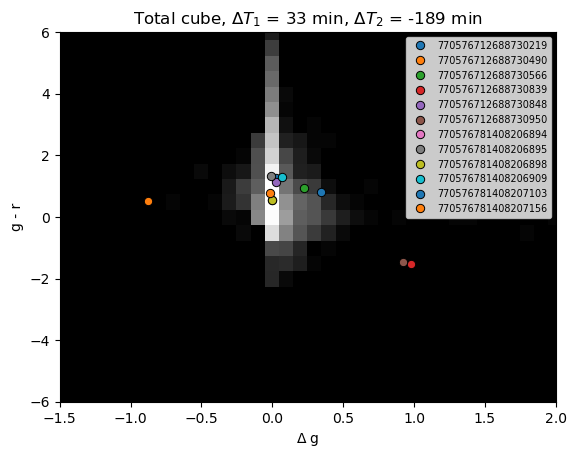

In [28]:
TotalCubePath = "/lustre/lrspec/users/4300/cube/Data/Datacube/211_223_TotalCubeNorm.pkl"
with open(TotalCubePath, 'rb') as f:
    InfoDict = pickle.load(f)
    Cube = pickle.load(f)
        
# CubeNorm = Cube / Cube2.max(-1, keepdims=True).max(-2, keepdims=True)
# np.nan_to_num(CubeNorm2, copy=False);


bandpairs = ["ir","gr"]
timepairs = [(-12,-223),(33,-189)]

q=1

Map1 = Enquiry(Cube, InfoDict, bandpairs[q][0], bandpairs[q][1], timepairs[q][0], timepairs[q][1])    

Map1 = Map1*100000

plt.pcolor(InfoDict['BinMag'], InfoDict['BinColor'], np.transpose(Map1)+1,
           norm=LogNorm(1, vmax=Map1.max()-1), cmap='gist_gray')

obj_dfs_filt = [obj_df for obj_df in obj_dfs if (len(obj_df[obj_df["Timepairs"]==timepairs[q]][obj_df[obj_df["Timepairs"]==timepairs[q]]["Bandpairs"]==bandpairs[q]]) > 0)]

for k, obj_pts in enumerate(obj_dfs_filt[0:12]):
                # axsflat[ii].plot(list(obj_pts["dMags"][obj_pts["Bandpairs"]== bandpairs[q]][obj_pts["Timepairs"]==timepairs[q]]),
                #                list(obj_pts["Colors"][obj_pts["Bandpairs"]== bandpairs[q]][obj_pts["Timepairs"]==timepairs[q]]), 
                #                mp_shapes[k], mec = "black", 
                #                  mew = 0.7, color = "#00dcbbff", ms = sizes[k])
                plt.plot(list(obj_pts["dMags"][obj_pts["Bandpairs"]== bandpairs[q]][obj_pts["Timepairs"]==timepairs[q]]),
                               list(obj_pts["Colors"][obj_pts["Bandpairs"]== bandpairs[q]][obj_pts["Timepairs"]==timepairs[q]]), 
                               "o", mec = "black", 
                                 mew = 0.7, label = obj_pts["Object Name"][0])

plt.xlim([-1.5, 2])
plt.ylim([-6, 6])
plt.legend(fontsize = "x-small")
plt.xlabel(f"$\\Delta$ {bandpairs[q][0]}", #size = "x-large"
          )
plt.ylabel(f"{bandpairs[q][0]} - {bandpairs[q][1]}")
title = f"$\\Delta T_1$ = {timepairs[q][0]} min, $\\Delta T_2$ = {timepairs[q][1]} min"
plt.title("Total cube, "+ title)